In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load PIB data
df_pib = pd.read_csv("data/ESTIMACIÓ_PIB_-_AGREGATS2462026_85023.csv", 
                      sep=";", encoding="utf-8-sig", decimal=",")

# Load visitors data  
df_visitors = pd.read_csv("data/NOMBRE_DE_VISITANTS_METODOLOGIA_20252462026_85517.csv",
                           sep=";", encoding="utf-8-sig", decimal=",")

df_visitors_country = pd.read_csv("data/NOMBRE_DE_VISITANTS_PER_PAÍS_DE_RESIDÈNCIA_METODOLOGIA_20252462026_85450.csv",
                                   sep=";", encoding="utf-8-sig", decimal=",")

print(df_pib.shape)
print(df_visitors.shape)
print(df_visitors_country.shape)

(6, 28)
(1, 54)
(3, 54)


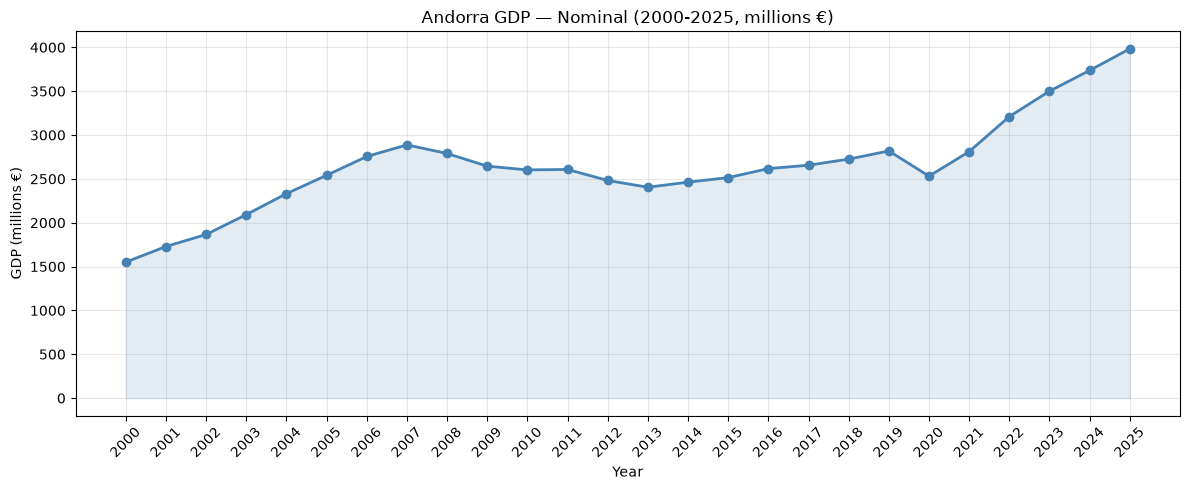

In [2]:
# Extract PIB nominal (first row) and years
years_pib = [col for col in df_pib.columns if col.isdigit()]
pib_nominal = df_pib[df_pib['Descripció'].str.contains('NOMINAL')].iloc[0][years_pib].astype(float).values

plt.figure(figsize=(12, 5))
plt.plot(years_pib, pib_nominal, marker='o', color='steelblue', linewidth=2)
plt.fill_between(years_pib, pib_nominal, alpha=0.15, color='steelblue')
plt.title("Andorra GDP — Nominal (2000-2025, millions €)")
plt.xlabel("Year")
plt.ylabel("GDP (millions €)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/gdp_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## 1. Andorra GDP Evolution (2000-2025)

Andorra's nominal GDP grew from €1.55B in 2000 to a historic high of €3.98B in 2025.
Two major crises are clearly visible: the 2008 financial crisis (peak €2.89B in 2007, 
not recovered until 2022 — a 15-year stagnation) and the COVID-19 shock in 2020.
The post-2021 acceleration reflects strong recovery driven by tourism and commerce.

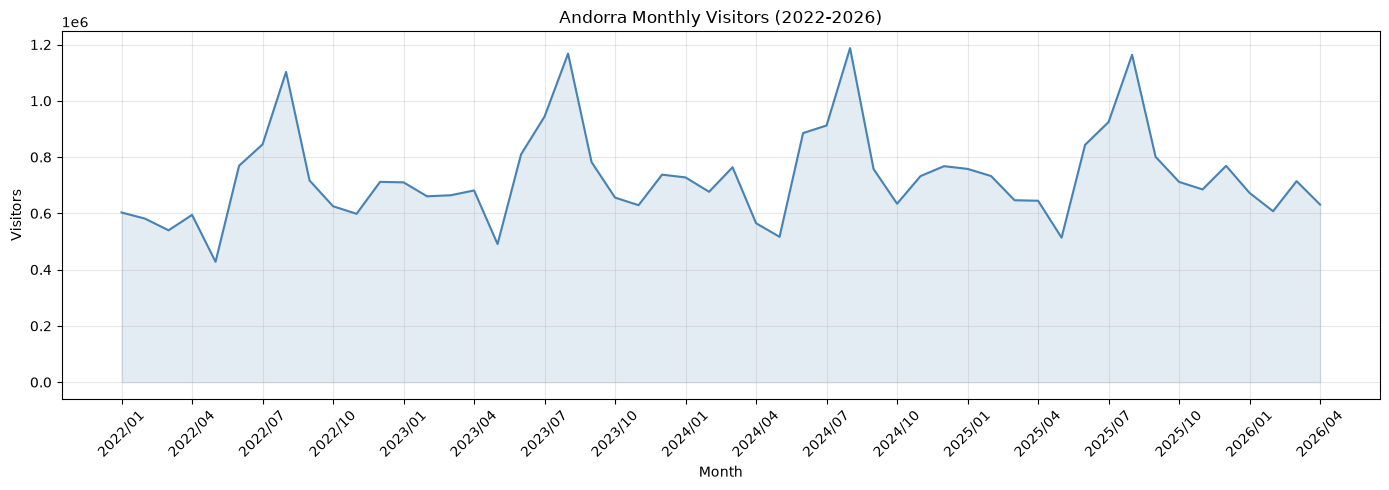

In [3]:
# Extract monthly visitor data
months = [col for col in df_visitors.columns if '/' in col]
visitors_total = df_visitors[months].iloc[0].astype(float).values

# Create month labels
month_labels = months

plt.figure(figsize=(14, 5))
plt.plot(month_labels, visitors_total, color='steelblue', linewidth=1.5)
plt.fill_between(range(len(month_labels)), visitors_total, alpha=0.15, color='steelblue')
plt.title("Andorra Monthly Visitors (2022-2026)")
plt.xlabel("Month")
plt.ylabel("Visitors")
plt.xticks(range(0, len(month_labels), 3), month_labels[::3], rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/visitors_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Monthly Visitor Seasonality (2022-2026)

Andorra shows a clear dual-season tourism pattern: 
a primary peak in July-August (~1.1M visitors/month) driven by summer shopping and leisure,
and a secondary peak in January-February driven by ski tourism at Grandvalira.
April-May and October-November are consistent low seasons.
This pattern repeats with high regularity across all years, 
reflecting Andorra's structural dependence on seasonal tourism.